In [63]:
import pandas as pd
import nfl_data_py as nfl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [65]:
import sqlite3
import pandas as pd
DATABASE_NAME = 'odds.db'
#SOURCE_DB = r'C:\Users\rfo7799\Downloads\odds.db'

conn = sqlite3.connect(DATABASE_NAME)
table_name = 'player_props'
prop_df = pd.read_sql(f"""
                 SELECT * FROM {table_name} WHERE market_type = 'player_pass_yds'
                 --AND lower(event_name) like '%tit%'
                 """, conn)
#prop_df


In [ ]:
#years = [2022, 2023, 2024, 2025]
#pbp = nfl.import_pbp_data(years=years, downcast=True)
#season = nfl.import_seasonal_data(years=years, s_type = 'REG')
#weekly = nfl.import_weekly_data(years=years)

#print('Play by Play Shape and Sample', pbp.shape, list())
#print('Season sample:')
#print(season.head(3))
#print('Weekly sample:')
#print(weekly.head(3))

#top_pass_2024 = (
#    weekly.query("season == 2024 and season_type == 'REG' and position == 'QB'")
#    .groupby(['player_id', 'player_display_name'], as_index=False)['passing_yards']
#    .sum()
#    .sort_values('passing_yards', ascending=False)
#)

#top_pass_2024.head()



In [11]:
# Select only the relevant columns
columns = ['passer_player_name', 'game_id', 'posteam', 'defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards', 
           'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
           'passing_yards', 'cpoe', 'roof', 'surface','drive','game_seconds_remaining']

# Loading in the NFL pbp data
data = nfl.import_pbp_data(range(2010,2026), downcast=True)
data = data[columns]

# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
data = data[columns]

# Drop all rows that are not a pass
data = data[(data['play_type'] == 'pass')]

# Drop the play type column
passer_data = data.drop(columns=['play_type'])

2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
2016 done.
2017 done.
2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.


In [13]:
# Group the data together by passer, week, season and aggregate
passer_df = passer_data.groupby(['passer_player_name', 'game_id', 'week', 'season'], as_index=False).agg(
    {'posteam' : 'first',
     'defteam' : 'first',
     'home_team' : 'first',
     'away_team' : 'first',
     'air_yards' : 'sum',
     'yards_after_catch' : 'sum',
     'epa' : 'sum',
     'complete_pass' : 'sum',
     'incomplete_pass' : 'sum',
     'interception' : 'sum',
     'qb_hit' : 'sum',
     'sack' : 'sum',
     'pass_touchdown' : 'sum',
     'passing_yards' : 'sum',
     'cpoe' : 'mean',
     'roof' : 'first',
     'surface' : 'first'
     }
)

# Create a new column that is completion percentage
passer_df['completion_percentage'] = passer_df['complete_pass'] / (passer_df['complete_pass'] + passer_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
passer_df['pass_attempts'] = passer_df['complete_pass'] + passer_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
passer_df = passer_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the passer is the home team and 0 if the passer is the away team
passer_df['home_flag'] = passer_df['home_team'] == passer_df['posteam']

passer_df = passer_df.drop(columns=['home_team','away_team'])



# Reorder the columns
#passer_df = passer_df[['passer_player_name', 'posteam', 'defteam', 'season', 'week', 'passing_yards', 'home_flag', 'completion_percentage', 'pass_attempts',
#                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
#                        'cpoe', 'roof', 'surface','total_offense_seconds']]

In [14]:
# Assuming 'pbp' is your play-by-play DataFrame from nfl_data_py
drives = data[['game_id', 'drive', 'game_seconds_remaining', 'posteam']].copy()

# Sort the data by game and drive to ensure correct ordering
drives = drives.sort_values(by=['game_id', 'drive', 'game_seconds_remaining'], ascending=[True, True, False])

# Drop duplicates to get the start and end of each drive
drive_starts = drives.groupby(['game_id', 'drive']).first().reset_index()
drive_ends = drives.groupby(['game_id', 'drive']).last().reset_index()

# Merge the start and end times to calculate the duration
drive_durations = pd.merge(drive_starts, drive_ends, on=['game_id', 'drive', 'posteam'], suffixes=('_start', '_end'))

# Calculate the duration of each drive in seconds
drive_durations['drive_duration_seconds'] = drive_durations['game_seconds_remaining_start'] - drive_durations['game_seconds_remaining_end']

# Group by game and team to get total TOP
game_top = drive_durations.groupby(['game_id', 'posteam']).agg(
    total_top_seconds=('drive_duration_seconds', 'sum')
).reset_index()

passer_df_merged = passer_df.merge(game_top, on=['game_id', 'posteam'], how='inner')
passer_df_merged.drop('game_id', axis=1, inplace=True)
passer_df_merged.head()

,passer_player_name,week,season,posteam,defteam,air_yards,yards_after_catch,epa,interception,qb_hit,sack,pass_touchdown,passing_yards,cpoe,roof,surface,completion_percentage,pass_attempts,home_flag,total_top_seconds
0,A.Andrews,14,2015,TEN,NYJ,26.0,15.0,3.954364,0.0,0.0,0.0,1.0,41.0,66.256546,outdoors,fieldturf,1.000000,1.0,False,972.0
1,M.Mariota,14,2015,TEN,NYJ,411.0,97.0,-9.227109,1.0,8.0,5.0,0.0,274.0,-5.209219,outdoors,fieldturf,0.552632,38.0,False,972.0
2,A.Beck,16,2019,DEN,DET,-3.0,9.0,2.351546,0.0,0.0,0.0,0.0,6.0,14.173185,outdoors,grass,1.000000,1.0,True,1339.0
3,D.Lock,16,2019,DEN,DET,222.0,86.0,4.990921,0.0,1.0,0.0,1.0,192.0,9.010706,outdoors,grass,0.757576,33.0,True,1339.0
4,A.Boldin,3,2010,BAL,CLE,-11.0,5.0,-1.045923,0.0,0.0,0.0,0.0,-6.0,56.395672,outdoors,fieldturf,1.000000,1.0,True,939.0


In [15]:
ewma_cols = ['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 'epa', 'interception', 
             'qb_hit', 'sack', 'pass_touchdown', 'passing_yards', 'cpoe','total_top_seconds']

passer_df = passer_df_merged.sort_values(by=['passer_player_name', 'season', 'week']).reset_index(drop=True)

for col in ewma_cols:
    new_col_name = f'{col}_ewma'
    
    # Group by player, apply EWM (which is calculated cumulatively), and then shift
    passer_df[new_col_name] = passer_df.groupby('passer_player_name')[col]\
        .transform(lambda x: x.ewm(min_periods=1, span=10).mean().shift(1))

columns_to_drop = [col for col in ewma_cols if col != 'passing_yards']
# 3. Drop the non-ewma columns
passer_df = passer_df.drop(columns=columns_to_drop)

In [16]:
# Select only the relevant columns
defense_columns = ['defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards',
                   'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
                   'passing_yards', 'cpoe', 'roof', 'surface']


# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
defense_data = data[defense_columns]

# Drop the play type column
defense_data = defense_data.drop(columns=['play_type'])



# Group the data together by passer, week, season and aggregate
defense_df = defense_data.groupby(['defteam', 'week', 'season'], as_index=False).agg(
    {'home_team': 'first',
     'away_team': 'first',
     'air_yards': 'sum',
     'yards_after_catch': 'sum',
     'epa': 'sum',
     'complete_pass': 'sum',
     'incomplete_pass': 'sum',
     'interception': 'sum',
     'qb_hit': 'sum',
     'sack': 'sum',
     'pass_touchdown': 'sum',
     'passing_yards': 'sum',
     'cpoe': 'mean',
     'roof': 'first',
     'surface': 'first'
     }
)

# Create a new column that is completion percentage
defense_df['completion_percentage'] = defense_df['complete_pass'] / (defense_df['complete_pass'] + defense_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
defense_df['pass_attempts'] = defense_df['complete_pass'] + defense_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
defense_df = defense_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the defense is the home team and 0 if the defense is the away team
defense_df['home_flag'] = defense_df['home_team'] == defense_df['defteam']

# Drop the home_team and away_team columns
defense_df = defense_df.drop(columns=['home_team', 'away_team'])

# Reorder the columns
defense_df = defense_df[['defteam', 'season', 'week', 'home_flag', 'passing_yards', 'completion_percentage', 'pass_attempts',
                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
                       'cpoe', 'roof', 'surface']]

In [17]:
# Create a list of columns to generate EWMA features for
ewma_cols = ['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 
             'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 'passing_yards', 'cpoe']

# Step 1: Sort the DataFrame chronologically by team, season, and week
# This is crucial for accurate time-series feature generation.
defense_df = defense_df.sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)

# Step 2: Calculate the EWMA for each feature, applying a .shift(1)
# The .shift(1) ensures the EWMA for the current week is based on data up to the PREVIOUS week.
for col in ewma_cols:
    new_col_name = f'{col}_ewma'
    defense_df[new_col_name] = defense_df.groupby('defteam')[col].transform(
        lambda x: x.ewm(min_periods=1, span=10).mean().shift(1)
    )

# Step 3: Drop the original, non-EWMA columns to prevent data leakage
defense_df = defense_df.drop(columns=ewma_cols)

In [20]:
# Merge the defense and passer dataframes together
df = passer_df.merge(defense_df, how='inner', on=['defteam', 'season', 'week', 'roof', 'surface'], suffixes=('_passer', '_defense'))
df = df[df['pass_attempts_ewma_passer'] > 5]

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_4944\1815020281.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataset_corr = df.corr()


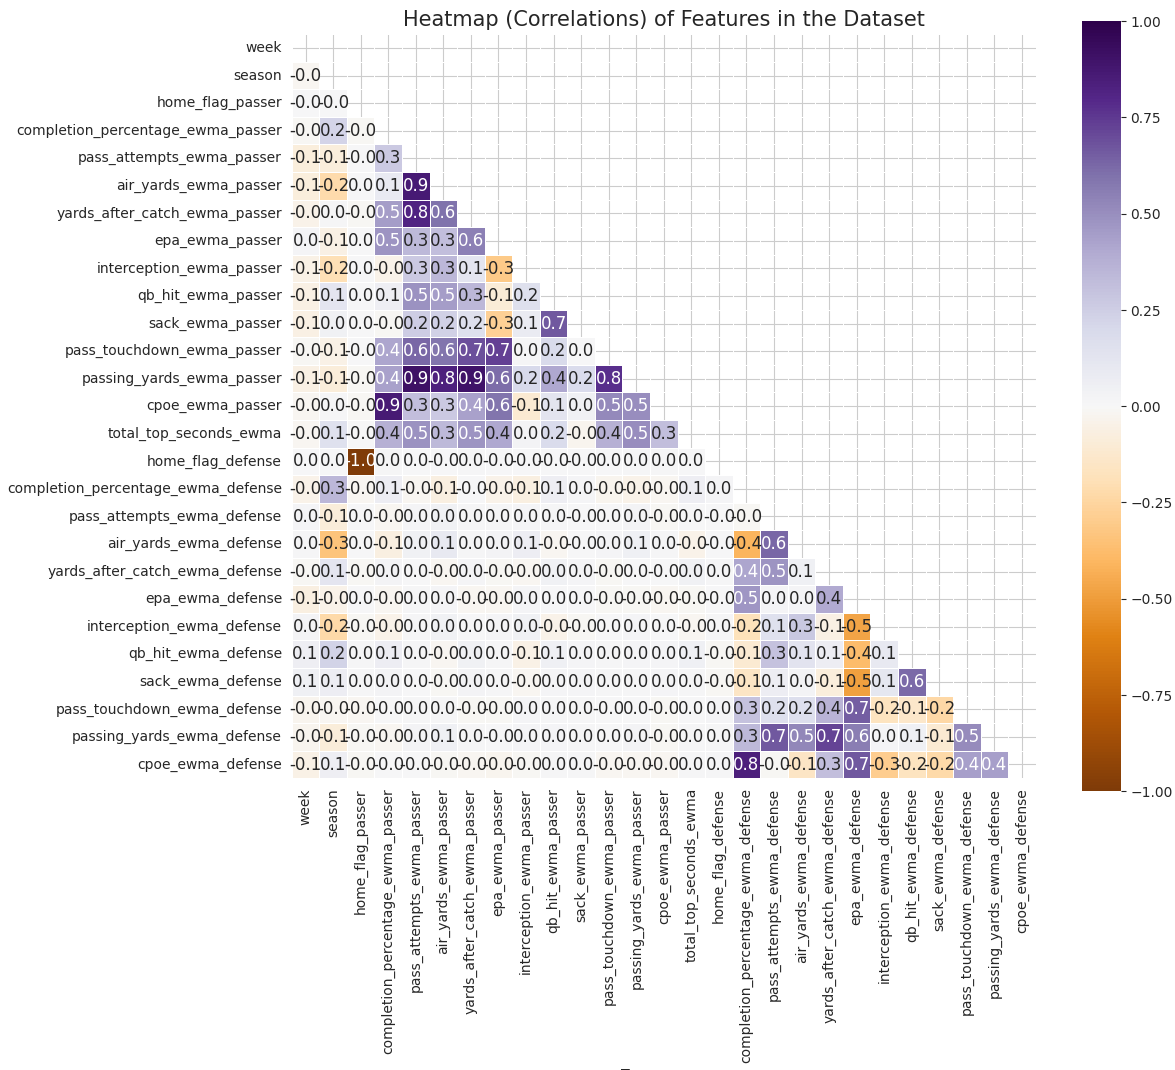

In [21]:
# Create a correlation for the dataset.
dataset_corr = df.corr()

# Drop Agent_ID from correlation dataset.
dataset_corr = dataset_corr.drop(['passing_yards'], axis=1)
dataset_corr = dataset_corr.drop(['passing_yards'], axis=0)

# Create a correlation matrix. Only bottom left corner valued.
mask = np.zeros_like(dataset_corr.round(4))
mask[np.triu_indices_from(mask)] = True

# Generate the corrleation matrix (heatmap) using Seaborn.
with sns.axes_style("whitegrid"):
    f, ax = plt.subplots(figsize=(12, 10))
    ax = sns.heatmap(dataset_corr.round(2), mask=mask, vmax=1, center=0, vmin=-1, square=True,
                     cmap='PuOr', linewidths=.5, annot=True, annot_kws={"size": 12}, fmt='.1f')
    plt.title('Heatmap (Correlations) of Features in the Dataset', fontsize=15)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Features', fontsize=15)
plt.show()

In [23]:
df.isnull().sum()
final_df = df.dropna()

In [44]:
from rapidfuzz import process, fuzz
import pandas as pd
import re

# 1. Prepare Name Lists
final_names = final_df['passer_player_name'].unique().tolist()
prop_names = prop_df['player_name'].unique().tolist()
search_choices = final_names # List to search against


def clean_name_minimal(name):
    """Standardizes names for better partial ratio matching: Lowercase, remove periods/suffixes."""
    name = name.lower()
    # Only remove the period, keep the initial separate (e.g., 'J.Hurts' -> 'j hurts')
    name = name.replace('.', ' ') 
    # Remove common suffixes
    name = re.sub(r'\s+(jr|sr|ii|iii|iv)\.?$', '', name)
    # Remove any extra spaces created
    name = re.sub(r'\s+', ' ', name).strip()
    return name


# 2. Create the Cleaned Search List and a Map to Retrieve Original Names
# NOTE: We clean prop_names (the queries) but keep final_names (the choices) as they are for the original map
cleaned_choices = [clean_name_minimal(n) for n in search_choices]

# Map from CLEANED final_name back to ORIGINAL final_name (for merge key)
clean_to_original_map = {clean_name_minimal(n): n for n in final_names}


# 3. Perform the Fuzzy Matching and Build the Match List (for ALL names)
matched_names = []
# partial_ratio requires a lower threshold than token_set, try 80
SCORE_THRESHOLD = 80

for name_prop in prop_names:
    # Clean the current name_prop for the query
    cleaned_query = clean_name_minimal(name_prop)

    best_match = process.extractOne(
        query=cleaned_query,
        choices=cleaned_choices,
        # --- KEY CHANGE: Use partial_ratio ---
        scorer=fuzz.partial_ratio,
        score_cutoff=SCORE_THRESHOLD
    )

    if best_match:
        # best_match is (cleaned_match, score, index)
        cleaned_match_name = best_match[0]
        score = best_match[1]
        
        # Get the original (uncleaned) name from final_df using the map
        original_final_name = clean_to_original_map.get(cleaned_match_name)

        matched_names.append({
            'prop_name': name_prop,
            'final_name_match': original_final_name,
            'similarity_score': score
        })
    else:
        # No match found above the threshold
        matched_names.append({
            'prop_name': name_prop,
            'final_name_match': None,
            'similarity_score': 0.0
        })

# 4. Create Match DataFrame and Map for Merging
match_df = pd.DataFrame(matched_names)

# Display sample results
print("--- Sample Name Matches (prop_df -> final_df) ---")
print(match_df[['prop_name', 'final_name_match', 'similarity_score']].sort_values(by='similarity_score', ascending=False))
print("-" * 50)
print("\n--- Unmatched Players (Score < {}) ---".format(SCORE_THRESHOLD))
print(match_df[match_df['final_name_match'].isna()])


# 5. Perform the Merge
# Create the map from prop_name (full name) to final_name (abbreviated name)
valid_matches = match_df.dropna(subset=['final_name_match'])
name_map = valid_matches.set_index('prop_name')['final_name_match'].to_dict()

# Create the common key column in prop_df using the map
prop_df['passer_player_name'] = prop_df['player_name'].map(name_map)

# Merge the DataFrames on the newly created common key
merged_df = final_df.merge(
    prop_df.drop(columns=['player_name']), # Drop the redundant name column from prop_df
    on='passer_player_name',
    how='left'
)

print("\n✅ Merge complete.")
print(merged_df)

--- Sample Name Matches (prop_df -> final_df) ---
            prop_name final_name_match  similarity_score
8        Daniel Jones          L.Jones        100.000000
20          Mac Jones          C.Jones        100.000000
14     Tua Tagovailoa     T.Tagovailoa         95.652174
4     Trevor Lawrence       T.Lawrence         94.736842
26     Caleb Williams       C.Williams         94.736842
19     Baker Mayfield       B.Mayfield         94.736842
9    Matthew Stafford       M.Stafford         94.736842
11       Dak Prescott       D.Prescott         94.736842
5         Sam Darnold        S.Darnold         94.117647
6     Spencer Rattler        S.Rattler         94.117647
25     Jayden Daniels        J.Daniels         94.117647
13      Aaron Rodgers        A.Rodgers         94.117647
21    Patrick Mahomes        P.Mahomes         94.117647
15     Justin Herbert        J.Herbert         94.117647
2       Justin Fields         J.Fields         93.333333
27       Kyler Murray         K.Murray

In [ ]:
# Identify categorical columns to be encoded
categorical_cols = ['passer_player_name', 'posteam', 'defteam', 'roof', 'surface']

# Perform one-hot encoding
final_df = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)
final_df = final_df[final_df['event_name'].isnull() == False]


In [ ]:
# Define your features (X) and target (y)
X = final_df.drop(['passing_yards','week','season'], axis=1)  # Features
y = final_df['passing_yards']              # Target

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Instantiate the models
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'SVR': SVR(),
}

# Regression models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'R-squared': r2, 'MAE': mae}

# Print the comparison results
results_df = pd.DataFrame(results).T.sort_values(by='RMSE')
print(results_df)

# You would choose the best model based on the lowest RMSE
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"\nThe best performing model is: {best_model_name}")

c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6193
[LightGBM] [Info] Number of data points in the train set: 7107, number of used features: 187
[LightGBM] [Info] Start training from score 221.147460


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


                   RMSE  R-squared        MAE
RandomForest  83.545876   0.233653  66.290433
LightGBM      83.892535   0.227280  66.848379
XGBoost       87.321472   0.162822  69.000671
SVR           88.900890   0.132264  69.192834

The best performing model is: RandomForest


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Fine-tuning LightGBM (assuming it was the best model)
lgbm = LGBMRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'reg_alpha': [0, 0.1, 0.5]
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

# Get the best model and its parameters
tuned_lgbm = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"\nBest parameters found: {grid_search.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6193
[LightGBM] [Info] Number of data points in the train set: 7107, number of used features: 187
[LightGBM] [Info] Start training from score 221.147460

Best parameters found: {'learning_rate': 0.01, 'n_estimators': 300, 'num_leaves': 31, 'reg_alpha': 0}


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Instantiate the RandomForest model
rf = RandomForestRegressor(random_state=42)

# Perform Grid Search with cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                              cv=5, scoring='neg_root_mean_squared_error',
                              n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train, y_train)

# Get the best model and its parameters
tuned_rf = grid_search_rf.best_estimator_
rf_best_params = grid_search_rf.best_params_
print(f"Best parameters found for RandomForest: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
405 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
184 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\skle

Best parameters found for RandomForest: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


In [ ]:
from sklearn.metrics import mean_absolute_error

lgbm_tuned_model = LGBMRegressor(**best_params, random_state=42)

lgbm_tuned_model.fit(X_train, y_train)
y_pred = lgbm_tuned_model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000998 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6193
[LightGBM] [Info] Number of data points in the train set: 7107, number of used features: 187
[LightGBM] [Info] Start training from score 221.147460
R2 Score: 0.25138863186234106
RMSE: 82.5734493447688
MAE: 65.69623812588381


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
from sklearn.metrics import mean_absolute_error

rf_tuned_model = RandomForestRegressor(**rf_best_params, random_state=42)

rf_tuned_model.fit(X_train, y_train)
y_pred = rf_tuned_model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

R2 Score: 0.25417872429744826
RMSE: 82.41942909332882
MAE: 65.60822865472309


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
from sklearn.linear_model import LinearRegression
# Define the meta-model
meta_model = LinearRegression()

# Train the base models on the training data
lgbm_tuned_model.fit(X_train, y_train)
rf_tuned_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5938
[LightGBM] [Info] Number of data points in the train set: 7107, number of used features: 186
[LightGBM] [Info] Start training from score 221.147460


RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=4,
                      min_samples_split=10, n_estimators=300, random_state=42)

In [ ]:
lgbm_preds = lgbm_tuned_model.predict(X_test)
rf_preds = rf_tuned_model.predict(X_test)

# Combine the predictions into a new DataFrame to serve as the meta-model's features
stacked_features = pd.DataFrame({
    'LGBM_preds': lgbm_preds,
    'RF_preds': rf_preds
})

# Train the meta-model on the base models' predictions
meta_model.fit(stacked_features, y_test)

# Make final predictions with the stacked ensemble
final_predictions = meta_model.predict(stacked_features)

# Evaluate the final ensemble model
mae = mean_absolute_error(y_test, final_predictions)
rmse = mean_squared_error(y_test, final_predictions, squared=False)

print(f"Ensemble Mean Absolute Error (MAE): {mae}")
print(f"Ensemble Root Mean Squared Error (RMSE): {rmse}")

Ensemble Mean Absolute Error (MAE): 65.59006507321648
Ensemble Root Mean Squared Error (RMSE): 82.2929607190884


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Assuming you have the best_params dictionary from GridSearchCV

# Train a model to predict the 10th percentile (lower bound)
lgbm_q10 = LGBMRegressor(objective='quantile', alpha=0.1, **best_params, random_state=42)
lgbm_q10.fit(X_train, y_train)

# Train a model to predict the 50th percentile (the median prediction)
lgbm_q50 = LGBMRegressor(objective='quantile', alpha=0.5, **best_params, random_state=42)
lgbm_q50.fit(X_train, y_train)

# Train a model to predict the 90th percentile (upper bound)
lgbm_q90 = LGBMRegressor(objective='quantile', alpha=0.9, **best_params, random_state=42)
lgbm_q90.fit(X_train, y_train)


# Assuming you have 'X_new' which is the pre-processed data for the game you want to predict
# X_new should be a single row DataFrame

# Get predictions from each of the quantile models
q10_prediction = lgbm_q10.predict(X_test)[0]
q50_prediction = lgbm_q50.predict(X_test)[0]
q90_prediction = lgbm_q90.predict(X_test)[0]

# Calculate the confidence interval and width
confidence_interval = (q10_prediction, q90_prediction)
interval_width = q90_prediction - q10_prediction

print(f"Prediction (Median): {q50_prediction:.2f} yards")
print(f"90% Confidence Interval: [{q10_prediction:.2f}, {q90_prediction:.2f}] yards")
print(f"Confidence Interval Width: {interval_width:.2f} yards")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6193
[LightGBM] [Info] Number of data points in the train set: 7107, number of used features: 187
[LightGBM] [Info] Start training from score 82.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6193
[LightGBM] [Info] Number of data points in the train set: 7107, number of used features: 187
[LightGBM] [Info] Start training from score 229.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of

In [22]:
import joblib
# Save the tuned LGBM model for rushing yards
#joblib.dump(rf_tuned_model, 'rf_passing_model.joblib')

# Save the tuned Random Forest model for rushing yards
joblib.dump(lgbm_tuned_model, 'lgbm_passing_model.joblib')
joblib.dump(lgbm_q10, 'lgbm_passing_q10_model.joblib')
joblib.dump(lgbm_q50, 'lgbm_passing_q50_model.joblib')
joblib.dump(lgbm_q90, 'lgbm_passing_q90_model.joblib')

print("All optimal models have been saved to disk.")

All optimal models have been saved to disk.
